<div>
<div style="font-size: 0.85em; letter-spacing: 0.08em; text-transform: uppercase; color: #1c4ed8; font-weight: 700; margin-bottom: 0.5em;">ML Research &middot; Rate Plan Design</div>
<h1 style="margin: 0 0 0.3em; font-weight: 800; letter-spacing: -0.01em;">Launch forecast, scoring, and recommendation</h1>
<p style="margin-top: 0; font-size: 1.2em; color: #444;">Notebook 2 of 2: turns the estimated choice models into a launch forecast, scores it against the withheld answer key, and recommends a launch configuration</p>
</div>

<div style="border: 2px solid #a94442; padding: 20px 30px;">
<h2>Disclosure</h2>
<ul style="margin-left: 0; padding-left: 1.25em;">
<li>All data and modeled results are synthetic, generated and validated in <code>data/00_generate_and_validate_data.ipynb</code>.</li>
<li>This notebook continues <code>01_choice_model_estimation.ipynb</code> and reads that notebook's saved outputs from <code>outputs/</code>; run it first.</li>
<li>Answer-key tables load only through <code>load_answer_key()</code>, and only in cells that score a finished forecast.</li>
</ul>
</div>

<hr>
<div>
<h2>Initialize Forecast Environment</h2>
<p>Initializes the shared imports, plotting style, file paths, constants, and helper functions used throughout sections 05–08. These match notebook 1, so either notebook runs on its own.</p>
</div>

In [1]:
# Standard Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
from scipy.special import logsumexp, softmax
from scipy.stats import norm, qmc
from IPython.display import display

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

In [2]:
# Plotting Theme and Color Palette
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'
TEAL = '#1f9e89'
PURPLE = '#7b4fc9'

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

In [3]:
# Data Loading and Export Helpers
DATA = Path('data/synthetic')
OUTPUTS = Path('outputs')
OUTPUTS.mkdir(exist_ok = True)

MODEL_TABLES = [
    'accounts', 'usage_panel', 'plan_events', 'plan_catalog', 'price_history', 'markets',
    'conjoint_responses', 'conjoint_respondents',
]
ANSWER_KEY_TABLES = [
    'ground_truth', 'true_plan_events', 'value_launch_counterfactual',
    'counterfactual_launch', 'counterfactual_grid', 'generator_parameters',
]


def load(name):
    """Loads a table the carrier could actually hold. Answer-key tables are refused."""

    if name in ANSWER_KEY_TABLES:
        raise PermissionError(f'{name} is part of the withheld answer key; use load_answer_key() only when scoring')
    if name not in MODEL_TABLES:
        raise KeyError(f'unknown table {name!r}')

    return pd.read_parquet(DATA / f'{name}.parquet')


def load_answer_key(name):
    """Loads a withheld table. Used only in scoring cells, never to fit or tune a model."""

    if name not in ANSWER_KEY_TABLES:
        raise KeyError(f'{name!r} is not an answer-key table')

    return pd.read_parquet(DATA / f'{name}.parquet')


def load_output(name):
    """Loads a table saved by an earlier section."""

    return pd.read_parquet(OUTPUTS / f'{name}.parquet')


def save_output(df, name):

    path = OUTPUTS / f'{name}.parquet'
    df.to_parquet(path, index = False)

    return path

In [4]:
# Domain Constants
ALTS = ['premium', 'standard', 'value', 'essentials', 'comp_premium', 'comp_value', 'outside']
OWN_PLANS = ['premium', 'standard', 'value', 'essentials']
ORIGINS = ['premium', 'standard', 'value', 'competitor', 'outside']
ORIGIN_OF = {
    'premium': 'premium', 'standard': 'standard', 'value': 'value',
    'comp_premium': 'competitor', 'comp_value': 'competitor', 'outside': 'outside',
}

N_MONTHS = 24
N_HORIZON = 12
ADDL_LINE_RATE = 0.65

ESSENTIALS_PRICES = np.arange(35.0, 55.1, 2.5)
ESSENTIALS_BUNDLES = ['lean', 'lean_hotspot', 'lean_30gb', 'lean_hd']
ELIGIBILITY = ['open', 'no_multiline_discount', 'new_lines_only']
CONFIG_KEYS = ['bundle', 'eligibility', 'essentials_price']
REFERENCE_CONFIG = ('lean', 'open', 45.0)

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>05 · Back-Test on the Value Launch</h1>
<p><strong>Purpose:</strong> Tests the whole approach on a launch that already happened. The models are refitted on months 1–13 only, used to forecast where <code>value</code> customers would come from after its month-14 launch, and scored against the true incremental source of volume.</p>
<p><strong>Architecture:</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Reasoning</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1</td><td style="text-align: left; vertical-align: top;">Refit on pre-launch history</td><td style="text-align: left; vertical-align: top;">A back-test is only honest if nothing after the launch informs the model.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2</td><td style="text-align: left; vertical-align: top;">Forecast months 14–24</td><td style="text-align: left; vertical-align: top;">Uses the same simulation machinery as section 06, so the back-test validates the forecast method, not a one-off calculation.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3</td><td style="text-align: left; vertical-align: top;">Three-way comparison</td><td style="text-align: left; vertical-align: top;">Carrier migration records, the forecast, and the true incremental source differ; the gaps show why source of volume cannot be read off plan events.</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>1 · Refitting on Pre-Launch History</h2>
<p><strong>Purpose:</strong> Re-estimates the section 03 model on months 1–13.</p>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>2 · Forecasting the Value Launch</h2>
<p><strong>Purpose:</strong> Simulates months 14–24 with and without <code>value</code>.</p>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>3 · Plan Events vs Forecast vs Truth</h2>
<p><strong>Purpose:</strong> Compares the source of volume in carrier records, in the forecast, and in the withheld counterfactual.</p>
<p><em>To be built.</em></p>
</div>

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>06 · The Launch Simulation</h1>
<p><strong>Purpose:</strong> Forecasts 12 months after launch for every configuration: how many households take <code>essentials</code>, which plan or carrier each would otherwise have been on, and the net contribution margin once downgrades, competitor wins, and saved churners are all counted.</p>
<p><strong>Architecture:</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Reasoning</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1</td><td style="text-align: left; vertical-align: top;">Consideration model on observable triggers</td><td style="text-align: left; vertical-align: top;">Most customers never re-shop; without this the forecast becomes an instant migration wave.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2</td><td style="text-align: left; vertical-align: top;">Paired monthly simulation with and without <code>essentials</code></td><td style="text-align: left; vertical-align: top;">Shared random draws make the difference between the two runs the launch effect alone.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3</td><td style="text-align: left; vertical-align: top;">Margin accounting over 12 months</td><td style="text-align: left; vertical-align: top;">Monthly revenue per line always makes a cheaper plan look worse; retention and acquisition only appear over a longer window.</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>1 · Consideration Model</h2>
<p><strong>Purpose:</strong> Estimates the monthly probability of re-shopping from triggers, calibrated to observed switching rates.</p>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>2 · Simulating 12 Months per Configuration</h2>
<p><strong>Purpose:</strong> Runs the paired simulation across 9 prices, 4 bundles, and 3 eligibility rules for each model in section 07.</p>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>3 · Source of Volume and Net Margin</h2>
<p><strong>Purpose:</strong> Decomposes <code>essentials</code> volume by origin and computes net 12-month margin against no launch, in the forecast format section 07 scores.</p>
<p><em>To be built.</em></p>
</div>

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>07 · Scoring Against the Answer Key</h1>
<p><strong>Purpose:</strong> Scores every model's launch forecast against the true outcome of each configuration. This is where the study's central claim is tested: that a flat logit overstates how much a cheaper plan takes from higher-margin plans, and by how much.</p>
<p><strong>Architecture:</strong> One harness scores every forecast the same way. A forecast is two tables: <code>volume</code>, households on <code>essentials</code> at month 12 by configuration and origin, and <code>net_margin</code>, 12-month margin versus no launch by configuration.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Metric</th><th style="text-align: left;">Definition</th><th style="text-align: left;">Why it matters</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">Volume error</td><td style="text-align: left; vertical-align: top;">Forecast minus true <code>essentials</code> households, as a share of truth</td><td style="text-align: left; vertical-align: top;">Take rate sizes the launch but does not decide it.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Origin distance</td><td style="text-align: left; vertical-align: top;">Total variation distance between forecast and true origin shares</td><td style="text-align: left; vertical-align: top;">Overall accuracy of the source of volume.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">High-margin share bias</td><td style="text-align: left; vertical-align: top;">Forecast minus true share drawn from <code>premium</code> and <code>standard</code></td><td style="text-align: left; vertical-align: top;">The cannibalization error itself, with its direction.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Margin error and sign agreement</td><td style="text-align: left; vertical-align: top;">Forecast minus true net margin; share of configurations where both agree on profit or loss</td><td style="text-align: left; vertical-align: top;">Whether the forecast gets the go or no-go right.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Decision regret</td><td style="text-align: left; vertical-align: top;">True margin of the best configuration minus true margin of the one the forecast picks</td><td style="text-align: left; vertical-align: top;">What following this forecast would actually cost.</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>1 · The Scoring Harness</h2>
<p><strong>Purpose:</strong> Builds the true outcome for each configuration from the answer key and defines the scoring function every forecast passes through.</p>
<p><strong>Design Notes:</strong></p>
<ol>
<li>Origins are collapsed to what a model can forecast: <code>premium</code>, <code>standard</code>, <code>value</code>, <code>competitor</code>, and <code>outside</code></li>
<li>A household's origin is its month-12 state in the world without <code>essentials</code>, so saved churners count as <code>competitor</code> or <code>outside</code>, not as downgrades</li>
<li>The chosen configuration is the forecast's highest net margin; regret is measured in true dollars</li>
</ol>
</div>

In [5]:
# Build Answer Key Outcomes
def true_outcomes():

    grid = load_answer_key('counterfactual_grid')
    on_essentials = grid[grid['state_b'] == 'essentials'].assign(origin = lambda d: d['state_a'].map(ORIGIN_OF))

    volume = (
        on_essentials.groupby(CONFIG_KEYS + ['origin'])['households'].sum()
            .unstack('origin').reindex(columns = ORIGINS).fillna(0)
    )
    net_margin = (grid.groupby(CONFIG_KEYS)['margin_b'].sum() - grid.groupby(CONFIG_KEYS)['margin_a'].sum()).rename('net_margin')

    return volume, net_margin.reindex(volume.index)

true_volume, true_margin = true_outcomes()
print(f'{len(true_volume)} configurations · {true_volume.to_numpy().sum():,.0f} essentials households across all of them')

108 configurations · 536,443 essentials households across all of them


In [6]:
# Define Scoring Harness
def score_forecast(volume, net_margin, truth = (true_volume, true_margin)):

    t_volume, t_margin = truth
    volume = volume.reindex(index = t_volume.index, columns = ORIGINS)
    net_margin = net_margin.reindex(t_volume.index)
    if volume.isna().any().any() or net_margin.isna().any():
        raise ValueError('forecast must cover every configuration and origin')

    f_total, t_total = volume.sum(axis = 1), t_volume.sum(axis = 1)
    f_share, t_share = volume.div(f_total, axis = 0), t_volume.div(t_total, axis = 0)
    high = ['premium', 'standard']

    by_config = pd.DataFrame({
        'volume error': (f_total - t_total) / t_total,
        'origin distance': 0.5 * (f_share - t_share).abs().sum(axis = 1),
        'high-margin share bias': f_share[high].sum(axis = 1) - t_share[high].sum(axis = 1),
        'margin error ($M)': (net_margin - t_margin) / 1e6,
        'sign agrees': np.sign(net_margin) == np.sign(t_margin),
    })

    chosen = net_margin.idxmax()
    summary = pd.Series({
        'mean |volume error|': by_config['volume error'].abs().mean(),
        'mean origin distance': by_config['origin distance'].mean(),
        'mean high-margin share bias': by_config['high-margin share bias'].mean(),
        'margin RMSE ($M)': np.sqrt((by_config['margin error ($M)'] ** 2).mean()),
        'margin sign agreement': by_config['sign agrees'].mean(),
        'chosen configuration': ' · '.join(str(k) for k in chosen),
        'decision regret ($M)': (t_margin.max() - t_margin.loc[chosen]) / 1e6,
    })

    return by_config, summary

<hr>
<div>
<h2>2 · Harness Checks</h2>
<p><strong>Purpose:</strong> Confirms the harness measures what it claims before any real forecast is scored, using three constructed forecasts.</p>
<p><strong>Design Notes:</strong></p>
<ol>
<li><strong>Truth:</strong> the answer key scored against itself must show zero error on every metric</li>
<li><strong>Inflated volume:</strong> every origin scaled up 20% must show a 20% volume error and no origin error</li>
<li><strong>Proportional origins:</strong> true totals, but split across origins in proportion to month-24 market shares, the way a flat logit would; it must show origin error and a positive high-margin share bias, with no volume error</li>
<li>These are checks on the harness, not forecasts; no model has been scored yet</li>
</ol>
</div>

In [7]:
# Run Harness Checks
truth_forecast = score_forecast(true_volume, true_margin)

inflated_forecast = score_forecast(true_volume * 1.2, true_margin)

month_24_shares = (
    load_answer_key('ground_truth')['plan_month_24'].map(ORIGIN_OF).value_counts(normalize = True).reindex(ORIGINS)
)
proportional_volume = pd.DataFrame(
    np.outer(true_volume.sum(axis = 1), month_24_shares), index = true_volume.index, columns = ORIGINS
)
proportional_forecast = score_forecast(proportional_volume, true_margin)

harness_checks = pd.DataFrame({
    'truth': truth_forecast[1],
    'inflated volume': inflated_forecast[1],
    'proportional origins': proportional_forecast[1],
})
display(harness_checks.map(lambda v: round(v, 4) + 0.0 if isinstance(v, float) else v).rename_axis(None))

,truth,inflated volume,proportional origins
mean |volume error|,0.0,0.2,0.0
mean origin distance,0.0,0.0,0.4233
mean high-margin share bias,0.0,0.0,0.2902
margin RMSE ($M),0.0,0.0,0.0
margin sign agreement,1.0,1.0,1.0
chosen configuration,lean_hd · new_lines_only · 40.0,lean_hd · new_lines_only · 40.0,lean_hd · new_lines_only · 40.0
decision regret ($M),0.0,0.0,0.0


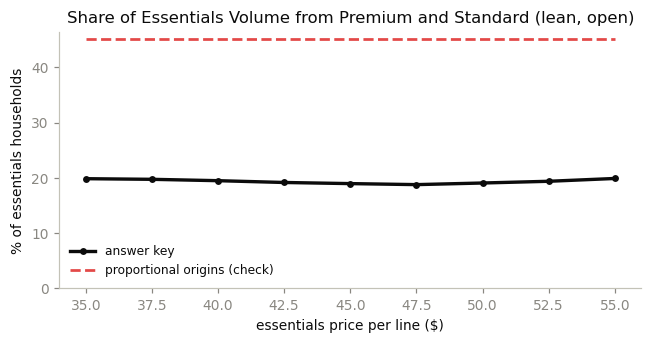

In [8]:
# Plot: Harness Check on the Reference Bundle
bundle, eligibility, _ = REFERENCE_CONFIG
prices = ESSENTIALS_PRICES
high = ['premium', 'standard']

def high_share(volume):
    v = volume.xs((bundle, eligibility), level = ['bundle', 'eligibility'])
    return v[high].sum(axis = 1) / v.sum(axis = 1)

fig, ax = plt.subplots(figsize = (6, 3.2))
ax.plot(prices, high_share(true_volume) * 100, color = INK, linewidth = 2.2, marker = 'o', markersize = 3.5, label = 'answer key')
ax.plot(prices, high_share(proportional_volume) * 100, color = RED, linewidth = 1.8, linestyle = '--', label = 'proportional origins (check)')
ax.set_ylim(bottom = 0)
ax.set_title('Share of Essentials Volume from Premium and Standard (lean, open)')
ax.set_xlabel('essentials price per line ($)')
ax.set_ylabel('% of essentials households')
ax.legend(frameon = False, fontsize = 8)
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>3 · Flat vs Nested vs Latent Class</h2>
<p><strong>Purpose:</strong> Scores the section 06 forecast from each model and compares them on every metric.</p>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>4 · Where Forecasts Go Wrong</h2>
<p><strong>Purpose:</strong> Breaks forecast error down by price, bundle, eligibility rule, and taste class.</p>
<p><em>To be built.</em></p>
</div>

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>08 · Recommendation and Rollout Design</h1>
<p><strong>Purpose:</strong> Chooses the launch configuration from the best-scoring model, states the boundary at which the decision would change, and designs a market-randomized rollout that measures the real effect.</p>
<p><strong>Architecture:</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Reasoning</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1</td><td style="text-align: left; vertical-align: top;">Configuration choice with a cannibalization ceiling</td><td style="text-align: left; vertical-align: top;">Margin is the objective, but a cap on the high-margin share protects against forecast error in the costliest direction.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2</td><td style="text-align: left; vertical-align: top;">Decision boundary</td><td style="text-align: left; vertical-align: top;">Shows how wrong the forecast would need to be before a different configuration wins.</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3</td><td style="text-align: left; vertical-align: top;">Market-randomized rollout with holdout markets</td><td style="text-align: left; vertical-align: top;">Launch intensity already varies at random across markets; a rollout that keeps holdouts turns the launch into a measurement.</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>1 · Choosing Price, Bundle, and Eligibility</h2>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>2 · Decision Boundary</h2>
<p><em>To be built.</em></p>
</div>

<hr>
<div>
<h2>3 · Rollout and Measurement Design</h2>
<p><em>To be built.</em></p>
</div>

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h3>The Complete Study Chain</h3>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Section</th><th style="text-align: left;">Role in the study</th><th style="text-align: left;">Question it answers</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">00 · Data Generation and Validation</td><td style="text-align: left; vertical-align: top;">Creates and validates the synthetic market and the withheld answer key</td><td style="text-align: left; vertical-align: top;">What would the study need to observe, and does the synthetic market contain it?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">01 · The Revealed-Preference Baseline</td><td style="text-align: left; vertical-align: top;">Estimates plan choice from carrier history alone</td><td style="text-align: left; vertical-align: top;">What does history identify, and where does it run out?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">02 · The Stated-Preference Mixed Logit</td><td style="text-align: left; vertical-align: top;">Values plan features and their variation across customers</td><td style="text-align: left; vertical-align: top;">What is each feature worth, and to whom?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">03 · The Joint RP–SP Nested Model</td><td style="text-align: left; vertical-align: top;">Combines both data sources with realistic substitution</td><td style="text-align: left; vertical-align: top;">Which plans substitute for which?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">04 · Latent Taste Classes</td><td style="text-align: left; vertical-align: top;">Segments customers by what they value</td><td style="text-align: left; vertical-align: top;">Which groups value which features?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">05 · Back-Test on the Value Launch</td><td style="text-align: left; vertical-align: top;">Validates the method on a past launch</td><td style="text-align: left; vertical-align: top;">Would it have been right before?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">06 · The Launch Simulation</td><td style="text-align: left; vertical-align: top;">Forecasts every launch configuration</td><td style="text-align: left; vertical-align: top;">What happens at each price, bundle, and rule?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">07 · Scoring Against the Answer Key</td><td style="text-align: left; vertical-align: top;">Measures each model's forecast error</td><td style="text-align: left; vertical-align: top;">How wrong is each forecast, and in which direction?</td></tr>
<tr><td style="text-align: left; vertical-align: top;">08 · Recommendation and Rollout Design</td><td style="text-align: left; vertical-align: top;">Turns the forecast into a launch decision</td><td style="text-align: left; vertical-align: top;">What should launch, and how will we know it worked?</td></tr>
</tbody>
</table>
</div>